<a href="https://colab.research.google.com/github/monicatom/Assignment/blob/main/CaseStudy_SupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

#preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler

#to train model
from sklearn.model_selection import train_test_split

#for logistic regression
from sklearn.linear_model import LogisticRegression

#for k-NN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#for Navie bayes
from sklearn.naive_bayes import GaussianNB

#for decision tree
from sklearn.tree import DecisionTreeClassifier

#for SVM
from sklearn.svm import SVC

#for gridsearchcv(model tuning)
from sklearn.model_selection import GridSearchCV #model fine tuning

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
filepath='/content/drive/MyDrive/DSA_ICTAK/Pratice_Data/Training_data.csv'
train_data=pd.read_csv(filepath)
train_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [4]:
train_data.shape

(5634, 21)

In [5]:
train_data.size

118314

In [6]:
train_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
train_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [8]:
#remove duplicates

train_data=train_data.drop_duplicates()

In [9]:
train_data.size

118314

In [10]:
train_data.nunique()

,0
customerID,5634
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [11]:
#missing values

train_data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [12]:
train_data.drop('gender', axis=1, inplace=True)

In [13]:
train_data.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,0,Yes,Yes,43,No,No phone service,DSL,NaN,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5465 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 


In [15]:
train_data['TotalCharges'] = pd.to_numeric(train_data['TotalCharges'], errors='coerce')
train_data['TotalCharges'].isnull().sum()

np.int64(290)

In [16]:
train_data['OnlineSecurity'] = train_data['OnlineSecurity'].fillna(train_data['OnlineSecurity'].mode()[0])
train_data['MonthlyCharges'] = train_data['MonthlyCharges'].fillna(train_data['MonthlyCharges'].median())
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(train_data['TotalCharges'].median())
train_data.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [17]:
train_data.isnull().sum()

,0
customerID,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Outlier handling

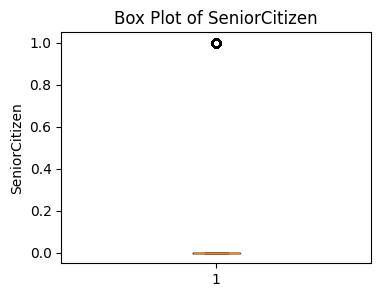

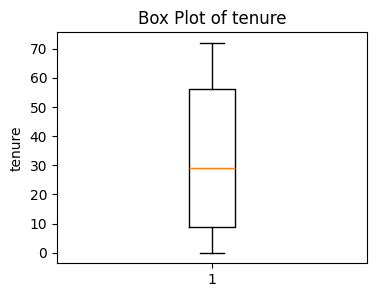

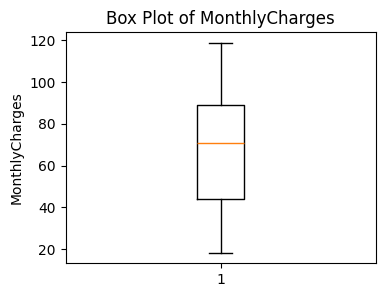

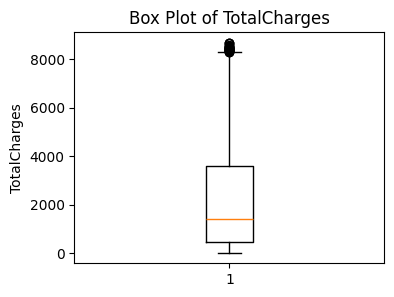

In [18]:
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(4, 3))
    plt.boxplot(train_data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


In [19]:
#remove outliers
#IQR

for col in num_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_data[col] = train_data[col].clip(lower, upper)
print(upper,lower)


8307.25 -4270.65


<Axes: >

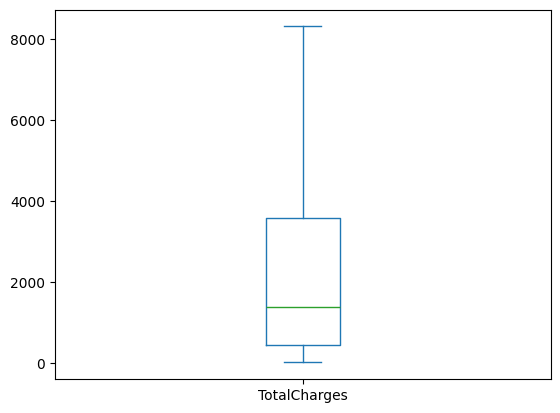

In [20]:
train_data['TotalCharges']=train_data['TotalCharges'].clip(lower=lower,upper=upper)
train_data['TotalCharges'].plot(kind='box')

Encoding

In [21]:
tpe_cols = train_data.select_dtypes(include=['object']).columns
tpe_cols

Index(['customerID', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [22]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    train_data[col] = train_data[col].map({'Yes': 1, 'No': 0})


scaling

In [23]:
scaler = StandardScaler()
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
train_data[num_cols]

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0.0,0.097232,-1.541793,-0.694206
1,0.0,-0.187173,-1.024876,-0.576355
2,0.0,0.950447,1.141008,1.509992
3,0.0,0.259749,-1.552131,-0.653763
4,0.0,0.422266,-0.490728,-0.038831
...,...,...,...,...
5629,0.0,0.747300,1.154792,1.264805
5630,0.0,1.437998,-0.811217,0.328859
5631,0.0,1.600515,-1.569362,-0.413115
5632,0.0,1.478627,0.584460,1.498363


Train Test Split

In [24]:
X = train_data.drop('Churn', axis=1)
y = train_data['Churn']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)


In [25]:
X_train.shape

(4507, 19)

In [26]:
X_test.shape

(1127, 19)

In [27]:
y_train.shape

(4507,)

In [28]:
y_test.shape

(1127,)

In [33]:
X_train.select_dtypes(include='object').columns

Index(['customerID', 'MultipleLines', 'InternetService', 'Contract',
       'PaymentMethod'],
      dtype='object')

In [35]:
cols_to_drop = ['customerID', 'MultipleLines', 'InternetService','Contract', 'PaymentMethod']

X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)


ML Modeling

1.Logistic Regression

In [39]:
# initialising the ML model
lr = LogisticRegression()
# training the model using taining features and training targets
lr.fit(X_train,y_train)
# predict using the model and test features
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test,y_pred_lr)
prec_lr = precision_score(y_test,y_pred_lr,pos_label='Yes')
rec_lr = recall_score(y_test,y_pred_lr,pos_label='Yes')
f1_lr = f1_score(y_test,y_pred_lr,pos_label='Yes')

print(f"the accuracy of logistic regression model is :{acc_lr}")
print(f"the precision of logistic regression model is :{prec_lr}")
print(f"the recall of logistic regression model is :{rec_lr}")
print(f"the f1 of logistic regression model is :{f1_lr}")
confusion_matrix(y_test,y_pred_lr)

the accuracy of logistic regression model is :0.7533039647577092
the precision of logistic regression model is :0.6614785992217899
the recall of logistic regression model is :0.5537459283387622
the f1 of logistic regression model is :0.6028368794326241


array([[514,  87],
       [137, 170]])

k-NN

using manhattan

In [40]:
acc_list = []
neighbors_range = np.arange(1,20)

for k in neighbors_range:
#intialization the classifier for iteration
  classifier = KNeighborsClassifier(n_neighbors = k,metric = 'minkowski',p=2)

#training the ML model
  classifier.fit(X_train,y_train)

#predict using the trained ML model
  y_pred = classifier.predict(X_test)

#evaluate the ML model
  acc = accuracy_score(y_test,y_pred)

#populate acc_list with accuracy achived for each value of 'k'
  acc_list.append(acc)


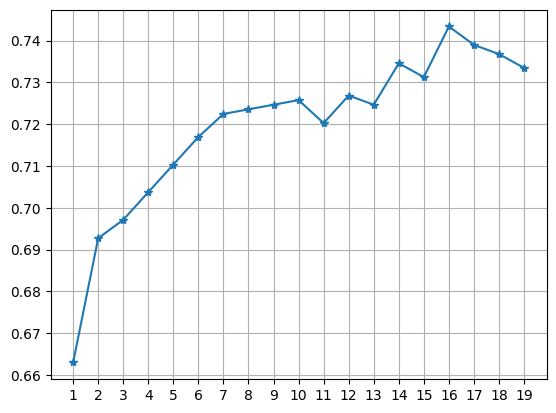

In [42]:
plt.plot(neighbors_range,acc_list,'*-')
plt.xlabel ='no of neighors (k)'
plt.ylabel = 'accuracy score'
plt.xticks(neighbors_range)
plt.grid()

Taking k=16

In [45]:
#initialzing the model
kNN_classifier=KNeighborsClassifier(n_neighbors=16,metric='manhattan')
#train model
kNN_classifier.fit(X_train,y_train)
#predict using the trained ML model
y_pred_knn=kNN_classifier.predict(X_test)
#Evaluate the ML model
acc_knn_mh=accuracy_score(y_test,y_pred_knn)
prrc_knn_mh=precision_score(y_test,y_pred_knn,pos_label='Yes')
recall_knn_mh=recall_score(y_test,y_pred_knn,pos_label='Yes')
f1_knn_mh=f1_score(y_test,y_pred_knn,pos_label='Yes')

In [46]:
print(f'The accuracy of kNN model is:{acc_knn_mh}')
print(f'The precision of kNN model is:{prrc_knn_mh}')
print(f'The recall of kNN model is:{recall_knn_mh}')
print(f'The f1 score of kNN model is:{f1_knn_mh}')
confusion_matrix(y_test,y_pred_knn)

The accuracy of kNN model is:0.7544052863436124
The precision of kNN model is:0.6764705882352942
The recall of kNN model is:0.5244299674267101
The f1 score of kNN model is:0.5908256880733945


array([[524,  77],
       [146, 161]])

using euclidean

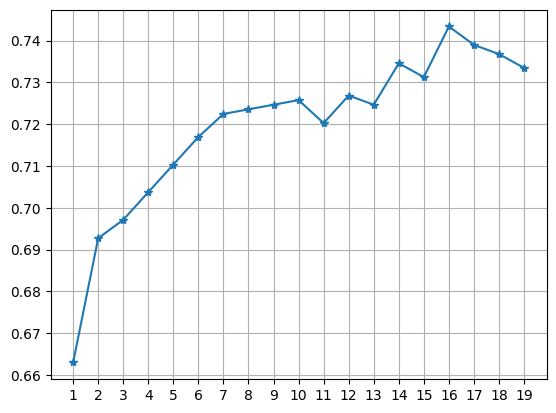

In [47]:
plt.plot(neighbors_range,acc_list,'*-')
plt.xlabel='No of neighbors(k)'
plt.ylabel='Accuracy Score'
plt.xticks(neighbors_range)
plt.grid()
plt.show()

In [48]:
#initialzing the model
kNN_classifier=KNeighborsClassifier(n_neighbors=18,metric='euclidean')
#train model
kNN_classifier.fit(X_train,y_train)
#predict using the trained ML model
y_pred_knn=kNN_classifier.predict(X_test)
#Evaluate the ML model
acc_knn=accuracy_score(y_test,y_pred_knn)
prrc_knn=precision_score(y_test,y_pred_knn,pos_label='Yes')
recall_knn=recall_score(y_test,y_pred_knn,pos_label='Yes')
f1_knn=f1_score(y_test,y_pred_knn,pos_label='Yes')

In [49]:
print(f'The accuracy of kNN model is:{acc_knn}')
print(f'The precision of kNN model is:{prrc_knn}')
print(f'The recall of kNN model is:{recall_knn}')
print(f'The f1 score of kNN model is:{f1_knn}')
confusion_matrix(y_test,y_pred_knn)

The accuracy of kNN model is:0.736784140969163
The precision of kNN model is:0.6452991452991453
The recall of kNN model is:0.49185667752442996
The f1 score of kNN model is:0.5582255083179297


array([[518,  83],
       [156, 151]])

Navie Baye's

In [50]:
#initializing the model
NB_classifier=GaussianNB()
#trainig the model
NB_classifier.fit(X_train,y_train)
#predict using the trained model
y_pred_NB=NB_classifier.predict(X_test)
#Evaluate the trained model
acc_NB=accuracy_score(y_test,y_pred_NB)
prrc_NB=precision_score(y_test,y_pred_NB,pos_label='Yes')
recall_NB=recall_score(y_test,y_pred_NB,pos_label='Yes')
f1_NB=f1_score(y_test,y_pred_NB,pos_label='Yes')

In [51]:
print(f'The accuracy of kNN model is:{acc_NB}')
print(f'The precision of kNN model is:{prrc_NB}')
print(f'The recall of kNN model is:{recall_NB}')
print(f'The f1 score of kNN model is:{f1_NB}')
confusion_matrix(y_test,y_pred_NB)

The accuracy of kNN model is:0.710352422907489
The precision of kNN model is:0.5572916666666666
The recall of kNN model is:0.6970684039087948
The f1 score of kNN model is:0.6193921852387844


array([[431, 170],
       [ 93, 214]])

Decision Tree

In [52]:
#initializing the model
Dtree_Classifier=DecisionTreeClassifier()
#trainig the model
Dtree_Classifier.fit(X_train,y_train)
#predict using the trained model
y_pred_Dtree=Dtree_Classifier.predict(X_test)
#Evaluate the trained model
acc_Dtree=accuracy_score(y_test,y_pred_Dtree)
prrc_Dtree=precision_score(y_test,y_pred_Dtree,pos_label='Yes')
recall_Dtree=recall_score(y_test,y_pred_Dtree,pos_label='Yes')
f1_Dtree=f1_score(y_test,y_pred_Dtree,pos_label='Yes')

In [53]:
print(f'The accuracy of decision tree is:{acc_Dtree}')
print(f'The precision of decision tree is:{prrc_Dtree}')
print(f'The recall of decision tree is:{recall_Dtree}')
print(f'The f1 score of decision tree is:{f1_Dtree}')
confusion_matrix(y_test,y_pred_Dtree)

The accuracy of decision tree is:0.6530837004405287
The precision of decision tree is:0.487012987012987
The recall of decision tree is:0.48859934853420195
The f1 score of decision tree is:0.4878048780487805


array([[443, 158],
       [157, 150]])

In [54]:
#intialization the classifier for iteration
svm = SVC()
#training the ML model
svm.fit(X_train, y_train)
#predict using the trained ML model
y_pred_svm = svm.predict(X_test)
#evaluate the ML model
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm,pos_label='Yes')
rec_svm = recall_score(y_test, y_pred_svm,pos_label='Yes')
f1_svm = f1_score(y_test, y_pred_svm,pos_label='Yes')

print("the accuracy of decision classifier model is :",acc_svm)
print("the precision of decision classifier  model is :",prec_svm)
print("the recall of decision classifier  model is :",rec_svm)
print("the f1 of ndecision classifier model is :",f1_svm)
confusion_matrix(y_test,y_pred_svm)

the accuracy of decision classifier model is : 0.748898678414097
the precision of decision classifier  model is : 0.6837209302325581
the recall of decision classifier  model is : 0.4788273615635179
the f1 of ndecision classifier model is : 0.5632183908045977


array([[533,  68],
       [160, 147]])

#Load Test Dataset

In [55]:
test=pd.read_csv('/content/drive/MyDrive/DSA_ICTAK/Pratice_Data/Testing_data.csv')
test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [56]:
test = test.drop('Churn', axis=1)

In [57]:
test = test.drop('customerID', axis=1)

In [58]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
  test[col] = test[col].map({'Yes': 1, 'No': 0})


In [60]:
multi_cols = ['gender','InternetService','Contract','PaymentMethod','StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineSecurity','MultipleLines','OnlineBackup']
test = pd.get_dummies(test, columns=multi_cols, drop_first=True)

In [61]:
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'],errors='coerce')

In [62]:
test['TotalCharges'].fillna(test['TotalCharges'].median(),inplace=True)

/tmp/ipython-input-837733687.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['TotalCharges'].fillna(test['TotalCharges'].median(),inplace=True)


In [71]:
test[num_cols] = scaler.transform(test[num_cols])

In [82]:
test

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,InternetService_Fiber optic,...,DeviceProtection_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,MultipleLines_No phone service,MultipleLines_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,Tenure_Contract_OneYear,Tenure_Contract_TwoYear,gender_Unknown
0,0.0,1,1,-1.378122,1,1,-2.333993,-1.011003,True,True,...,True,False,False,False,True,False,False,0,0,0
1,0.0,1,0,-1.380000,1,0,-2.334089,-1.011003,False,False,...,True,False,True,False,True,False,False,0,0,0
2,0.0,0,0,-1.377921,1,1,-2.333224,-1.011003,True,True,...,False,False,False,False,True,False,False,0,0,0
3,0.0,0,0,-1.375976,1,1,-2.332479,-1.011002,True,True,...,True,False,True,False,True,False,True,0,0,0
4,0.0,0,0,-1.380134,0,0,-2.335833,-1.011003,False,False,...,False,False,False,True,False,False,True,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,0.0,0,0,-1.378994,1,0,-2.335047,-1.011003,True,False,...,False,False,True,False,False,False,True,0,0,0
1405,1.0,0,0,-1.380671,1,1,-2.334228,-1.011003,False,True,...,False,False,False,False,True,False,False,0,0,0
1406,0.0,1,0,-1.380604,1,1,-2.334241,-1.011003,False,True,...,False,False,False,False,True,False,False,0,0,0
1407,0.0,1,1,-1.377251,1,0,-2.336489,-1.011003,True,False,...,False,True,False,False,False,True,False,0,0,0


In [83]:
missing_cols = ['Tenure_Contract_OneYear', 'Tenure_Contract_TwoYear', 'gender_Unknown']
for col in missing_cols:
    if col not in test.columns:
        test[col] = 0

In [85]:
train_columns = X_train.columns
test = test.reindex(columns=train_columns, fill_value=0)

In [86]:
y_pred = svm.predict(test)

In [87]:
pd.DataFrame(y_pred, columns=['Churn_Prediction']).head(20)

,Churn_Prediction
0,No
1,No
2,No
3,No
4,No
5,No
6,Yes
7,No
8,No
9,No


In [88]:
train_data['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


Model Tuning using GridSearchCV

In [89]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

In [91]:
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [92]:
grid_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan]
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='f1')

In [93]:
print("Best CV Score:", grid_lr.best_score_)
print("Best Parameters:", grid_lr.best_params_)

Best CV Score: nan
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
